<a href="https://colab.research.google.com/github/1up9059/tareas_curso_NLP/blob/Tareas/Tarea3_Text_Classification_ES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 3 — Clasificación de texto (ES)

Implementación de modelos Naive Bayes, Regresión Logística y SVM para las siguientes fuentes:
1. `sentiment_analysis_dataset.csv`
2. `Spanish News Classification.csv`

Incluye preprocesamiento para español, TF–IDF, GridSearchCV, métricas (accuracy, macro-F1), matrices de confusión, curvas de aprendizaje y guardado de modelos.


In [606]:
!pip install scikit-learn unidecode matplotlib seaborn pandas numpy tqdm

In [607]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [608]:

BASE_PATH = "/content/drive/MyDrive/source_NLP/inputs_NLP"
STOP_PATH = BASE_PATH + "/spanish_stop_words.txt"
SENT_PATH = BASE_PATH + "/sentiment_analysis_dataset.csv"
NEWS_PATH = BASE_PATH + "/Spanish News Classification.csv"

In [609]:
# Imports y configuración
import re, string, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from unidecode import unidecode

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import joblib

import nltk
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer('spanish')
from sklearn.utils.class_weight import compute_class_weight

sns.set(style="whitegrid")
RANDOM_STATE = 42


# Carga de stopwords de español

In [610]:
# Cargar stopwords personalizadas
try:
    with open(STOP_PATH, "r", encoding="utf-8") as f:
        custom_stopwords = set([w.strip().lower() for w in f if w.strip()])
    print("Stopwords cargadas:", len(custom_stopwords))

except FileNotFoundError:
    print(f"No se encontró '{STOP_PATH}'.")
    custom_stopwords = set()


Stopwords cargadas: 308


In [611]:
# Preprocesamiento en español
def clean_spanish_text(text, remove_numbers=False, do_stem=False, extra_stopwords=None):
  '''
  Definimos la función de limpieza con los siguiente parametros:
  text: el texto original a usar.
  remove_numbers: True, que elimina digitos del texto
  do_stem: False, para no aplicar steaming por default
  extra_stopwords: None, para no agregar mas stopwords por default, solo las del archivo
  '''
  t = str(text).lower()#Convertimos texto a minuscula

  #Eliminamos diacriticos y acentos, mantenemos ñ
  replacements = (("á","a"),("é","e"),("í","i"),("ó","o"),("ú","u"),("ü","u"))
  for orig, repl in replacements:
    t = t.replace(orig, repl)
  #t = unidecode(t)
  t = re.sub(r"http\S+|www\.\S+|@\w+", " ", t)#Quitamos URLS
  #En este caso:
  #http\S+: “http” seguido de no-espacios (URLs).
  #www\.\S+: dominios que empiezan con www..
  #@\w+: menciones tipo @usuario.

  #Ahora eliminamos trasliteraciones ascii, usando la tabla translate,
  #Ademas quitamos los siguinos de puntuación como .,;:!?¿¡"()[]{}#@, etc
  t = t.translate(str.maketrans("", "", string.punctuation))

  #si remove_number True, eliminamos digitos
  if remove_numbers:
    t = re.sub(r"\d+", " ", t)
  #tokenizamos el texto haciendo split por espacio, suficiente para BOW
  tokens = t.split()

  #Ahora samos las stopwords cargadas desde el archivo, usando un set para busqueda rapida
  sw = set(custom_stopwords)

  #convertimos las stopwors a minusculas,  y las convertimos a un set nuevamente
  if extra_stopwords:
    sw |= set(map(str.lower, extra_stopwords))

  #Eliminamos las stopwords. Eliminamos todo token que no tengal len mayor a 1
  #esto permite mantener palabras como si y no
  tokens = [tok for tok in tokens if tok not in sw and len(tok) > 1]

  #Si do_stem True entonces hacemos steaming de las palabras para simplicar
  if do_stem and stemmer is not None:
    tokens = [stemmer.stem(tok) for tok in tokens]
  #Retornamos el texto limpio
  text = {"clean_text": " ".join(tokens), "tokens": tokens}
  return text


In [612]:
# Utilidades de evaluación
def evaluate_model(estimator, X_test, y_test, model_name, title="Resultados"):
    '''
    estimator: Es el modelo a usar, en este caso los modelos usados de Bayesiano Ingenuos
               Regresión logistica o SVM
    X_train, y_train: son los datos de entrenamiento
    X_test, y_test: Son los datos de prueba usados
    title: Es el titulo del grafico
    '''

    #usamos el modelo que se evalua al momento para predecir las etiquetas
    y_pred = estimator.predict(X_test)

    #Calculamos la proporcion de aciertos totales
    acc = accuracy_score(y_test, y_pred)

    #Calculamos F1-score clase por clase (usando el mismo peso para cada clase)
    f1m = f1_score(y_test, y_pred, average="macro")

    #Imprimimos resultados
    print(f"\n{title}")
    print(f"Accuracy: {acc:.4f} | Macro-F1: {f1m:.4f}\n")#a resultados a 4 decimales
    report = classification_report(y_test, y_pred)
    report_df = pd.DataFrame.from_dict(classification_report(y_test, y_pred, output_dict=True))
    report_df = report_df.transpose()


    print(report)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusión — {title}")
    plt.xlabel("Predicho"); plt.ylabel("Real")
    plt.tight_layout(); plt.show()
    return { f"acc_{estimator}":acc, f"f1m_{estimator}":f1m, f"report_{model_name}": report_df}

In [613]:
def plot_learning_curves(estimator, X, y, cv=5, title="Curva de aprendizaje"):
  '''
  estimador: Es el modelo a usar, en este caso los modelos usados de Bayesiano Ingenuos
             Regresión logistica o SVM
  X: Son los datos de entrenamiento
  y: Son los datos de prueba usados
  cv: es el numero de particiones para la evaluación curzada del modelo
  '''

  #Usamos la función learning_curve de sklearn para calcular el rednimiento con sistintos tamaños de entranmieto
  #Usamos los parametrso 0.1, 1.0, y 5, que equivalen subconjuntos de 10%, 32.5%, 55%, 77.5%, y 100% de los datos.
  #scoring es suado para calcular el F1
  #cv para la validación cruzada
  #n_jobs=-1 para usar todos lo nucleos de procesamiento.
  #return_times=True para poder devolver los tiempos de entrenamiento del modelo
  #shuffle=True, y usamos el random_state = 42 definido al inicio, para mezclar los datos aleatoriamente.@
  train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
      estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5),
      return_times=True, scoring="f1_macro", shuffle=True, random_state=RANDOM_STATE)

  #Graficamos los resultados
  plt.figure()
  plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="F1 macro (train)")
  plt.plot(train_sizes, test_scores.mean(axis=1), marker="o", label="F1 macro (val)")
  plt.title(title); plt.xlabel("Tamaño de entrenamiento"); plt.ylabel("F1 macro")
  plt.legend()
  plt.tight_layout();
  plt.show()

In [614]:
# Top features (Sentimiento)
def show_top_features(clf_pipeline, vect_type, top_k=20):
    # con vec extraemos el vectorizador desde los pipelines para TF-IDF y bag of words
    # con clf extraemos el clasificador
    # luego extraemos las caracteristicas que creo la vectorización mediante feature names
    vec = clf_pipeline.named_steps[vect_type]
    clf = clf_pipeline.named_steps["clf"]
    feature_names = np.array(vec.get_feature_names_out())
    top_features = {}

    # luego para el LR y el SVM obtenemos los pesos de cada palabra
    # selecccionamos luego el top k de las palabras encontradas
    # invertimos entonces el orden e imprimimos las palabras
    if hasattr(clf, "coef_"):
        for i, class_label in enumerate(clf.classes_):
            coefs = clf.coef_[i]
            top = np.argsort(coefs)[-top_k:]
            print(f"\nTop for class '{class_label}':")
            print(feature_names[top][::-1])
            top_features[str(class_label)] = feature_names[top][::-1].tolist()

    # Lo mismo que el anterior pero para Multinomial NB, sacamos la probabilidad
    # de cada palabra en cada clase, luego las ordenamos
    elif hasattr(clf, "feature_log_prob_"):
        for i, class_label in enumerate(clf.classes_):
            top = np.argsort(clf.feature_log_prob_[i])[-top_k:]
            print(f"\nTop for class '{class_label}':")
            print(feature_names[top][::-1])
            top_features[str(class_label)] = feature_names[top][::-1].tolist()
    # si el clasificador no tiene nada de eso entonces imprimimos este mensaje
    else:
        print("Clasificador no soporta coeficientes.")

    return top_features




## 1) Dataset de Sentimiento — carga y limpieza


Primeramente leemos el dataframe de sentiment analysis

In [615]:
#Leemos el CSV de sentimiento
df_sent = pd.read_csv(SENT_PATH, encoding="utf-8")
print("Dataframe shape:", df_sent.shape); print("\nColumnas:", list(df_sent.columns))
df_sent.head()



Dataframe shape: (2590, 5)

Columnas: ['user', 'text', 'date', 'emotion', 'sentiment']


,user,text,date,emotion,sentiment
0,@erreborda,termine bien abrumado después de hoy,"Jan 6, 2024 · 2:53 AM UTC",overwhelmed,scared
1,@shpiderduck,me siento abrumado,"Jan 6, 2024 · 2:35 AM UTC",overwhelmed,scared
2,@Alex_R_art,Me siento un poco abrumado por la cantidad de ...,"Jan 6, 2024 · 12:20 AM UTC",overwhelmed,scared
3,@anggelinaa97,Salvador la única persona que no la ha abrumad...,"Jan 5, 2024 · 10:38 PM UTC",overwhelmed,scared
4,@diegoreyesvqz,Denme un helado o algo que ando full abrumado.,"Jan 5, 2024 · 8:38 PM UTC",overwhelmed,scared


Ejecutamos la ideitificación de las columnas que requerimos, y eliminamos la columnas no necesarias y las filas "sucias"

In [616]:
# Detectar columnas de texto y etiqueta

#Identificamos las columnas del data fame para las cuales queremos trabajar. Aqui creamos la lista de columnas a usar
text_col_candidates = [c for c in df_sent.columns if c.lower() in ("text","texto","review","sentence","comment")]
label_col_candidates = [c for c in df_sent.columns if c.lower() in ("label","sentiment","target","polarity","categoria","clasificacion")]

#bucasmos entonces las columnas. Si se encuentra usamos entonces la columna text como pirmera col del dataframe
#Si no usamos la ultima.
text_col = text_col_candidates[0] if text_col_candidates else df_sent.columns[0]
label_col = label_col_candidates[0] if label_col_candidates else df_sent.columns[-1]

#Tomamos le dataframe solo para text y sentiment.
df_sent = df_sent[[text_col, label_col]].rename(columns={text_col:"text", label_col:"sentiment"})
#Hacemos dropnan de df_sent y tambien un reset index para volver los indices a numeración corriente.
df_sent = df_sent.dropna(subset=["text","sentiment"]).reset_index(drop=True)
print(df_sent["sentiment"].value_counts())


sentiment
peaceful    660
mad         530
powerful    420
sad         360
joyful      350
scared      270
Name: count, dtype: int64


Ahora las siguientes lineas de codigo aplican el clean_spanish_text para las filas del df en la columna "text", eso tokeniza, hace steaming, lo que genera listas de palabras y las guarda en una nueva columna que se llama "clean_text"

In [617]:
# La siguiente linea de codigo crea la columna clean text a apartir de la columna text
# esta linea aplica la función lambda para clean_spanish_text recorriendo cada fila del df
# limpiando los toques para remover numero, y haciendo steaming mediante snowball
df_sent["clean_text_stem"] = df_sent["text"].apply(lambda s: clean_spanish_text(s, remove_numbers=True, do_stem=True)[ "tokens"])
df_sent["clean_text_no_stem"] = df_sent["text"].apply(lambda s: clean_spanish_text(s, remove_numbers=True, do_stem=False)[ "tokens"])


# Ahora usamos el nuevo texto limpio para separalor en tes y training en una proprocion de 0.2 y 0.8
# Usamo una semilla aleatoria igual 42, para que los resultados sean iguales siempre
# Usamos la estratificación para mantener balanceo de clases.
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(df_sent["clean_text_stem"],
                                                            df_sent["sentiment"],
                                                            test_size=0.25,
                                                            random_state=42,
                                                            stratify=df_sent["sentiment"])
#len(X_train_s), len(X_test_s)

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(df_sent["clean_text_no_stem"],
                                                            df_sent["sentiment"],
                                                            test_size=0.25,
                                                            random_state=42,
                                                            stratify=df_sent["sentiment"])


In [618]:
df_sent.head()

,text,sentiment,clean_text_stem,clean_text_no_stem
0,termine bien abrumado después de hoy,scared,"[termin, bien, abrum, despu, hoy]","[termine, bien, abrumado, despues, hoy]"
1,me siento abrumado,scared,"[sient, abrum]","[siento, abrumado]"
2,Me siento un poco abrumado por la cantidad de ...,scared,"[sient, abrum, cantid, cos, quier, dibuj, ver,...","[siento, abrumado, cantidad, cosas, quiero, di..."
3,Salvador la única persona que no la ha abrumad...,scared,"[salvador, unic, person, abrum, versiones❤😒❤, ...","[salvador, unica, persona, abrumado, versiones..."
4,Denme un helado o algo que ando full abrumado.,scared,"[denm, hel, ando, full, abrum]","[denme, helado, ando, full, abrumado]"


# Analisis de sentimientos

###Analisis por *TF-IDF* (Bag of words ponderado)

Ejecutamos el pipeline para el analisis del texto. Este pipeline se hace mediante los modelos MultinomialNB(), LogisticRegression() y LinearSVC(), definidos en el diccionario pipelines, con los diferentes paramentros definidos en el diccionario param_grids. Es qui donde aplicamos la version TF-IDF, que es la version ponderada de bag of words. Esto se logra mediante el uso de TfidfVectorizer que estamos definiendo en la variable. La diferencia entre uno y otro metodo es la penalización de palabras que comunes. Hemos decidido utilizar esta version de bag of words por robustes ya que permite penalizar stoword qu etal vez no estan en la lista de stopwords.

El metodo *TF-IDF* convina Term Frequency (*TF*) con inversse document Frecuency (*IDF*) para penalizar los temrinos que aparence mucho en un documento. Por tanto, a diferencia de *Bag of Words* no realiza unicamente un conteo de palabras (Kumari, P., et. al, 2023).


Fuentes:
1. Kumari, P., Singh, A., & Saini, S. (2023). A Comparative Study on TF-IDF Feature Weighting Method. arXiv preprint arXiv:2308.04037. Recuperado de https://arxiv.org/abs/2308.04037

In [619]:
# Pipelines y grids (Sentimiento)

# primeramente definimos un vector TF-IDF para coverir el texto en numeros., usando unigramas y bigramas,
# segun el paramentro ngram_range, ademas ignoramos palabra que aparezcan menos de dos veces y mas de 90%

#tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)
tfidf = TfidfVectorizer(analyzer=lambda x: x,   # El texto ya esta tokenizado
                        preprocessor=None,
                        lowercase=False,        # ya tenemos el texto en lowecase
                        token_pattern=None,     # desactiva regexp por defecto
                        min_df=2, max_df=0.9)   #tomamos palabras que aparecen en mas de dos filas, pero en
                                                # del 90% de las veces

pipelines = {
    "MNB": Pipeline([("tfidf", tfidf), ("clf", MultinomialNB())]),
    "LR":  Pipeline([("tfidf", tfidf), ("clf", LogisticRegression(max_iter=2000, n_jobs=-1, class_weight="balanced"))]),
    "SVM": Pipeline([("tfidf", tfidf), ("clf", LinearSVC(class_weight="balanced"))])
}

param_grids = {
    "MNB": {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,2,5], "clf__alpha":[0.1,0.5,1.0]},
    "LR":  {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,2,5], "clf__C":[0.1,1.0,3.0], "clf__penalty":["l2"], "clf__solver":["lbfgs","saga"]},
    "SVM": {"tfidf__ngram_range":[(1,1),(1,2)], "tfidf__min_df":[1,2,5], "clf__C":[0.5,1.0,2.0]}
}

# la siguiente linea hace la validación cruzada estratificada, manteniendo la proporción de clases y usando la misma semilla
# aleatoria anterior para manter reproducibilidad.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# el siguiente for loop aplica cada uno de los modelos haciendo un GridSeachCV para el pipeline usando la metrica F1
# aqui se entrena el modelo con gri fit y buca los mejores parametros encontrados para luego guardarlos en "best_models_sent"
best_models_sent_tfidf_s = {}
best_models_sent_tfidf_ns = {}
for name, pipe in pipelines.items():
    print(f"=== GridSearch {name} (steming text, TF-IDF) ===")
    grid_tfidf_s = GridSearchCV(pipe, param_grids[name], scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
    grid_tfidf_s.fit(X_train_s, y_train_s)
    print("Best parameters:", grid_tfidf_s.best_params_)
    print("Best score:", grid_tfidf_s.best_score_)
    print()

    print(f"=== GridSearch {name} (no steming text, TF-IDF) ===")
    grid_ns = GridSearchCV(pipe, param_grids[name], scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
    grid_ns.fit(X_train_ns, y_train_ns)
    print("Best parameters:", grid_ns.best_params_)
    print("Best score:", grid_ns.best_score_)#Print the F1 macro
    print()

    best_models_sent_tfidf_s[f"{name}"] = grid_tfidf_s.best_estimator_
    best_models_sent_tfidf_ns[f"{name}"] = grid_ns.best_estimator_


=== GridSearch MNB (steming text, TF-IDF) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'clf__alpha': 0.1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best score: 0.5726405819299437

=== GridSearch MNB (no steming text, TF-IDF) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'clf__alpha': 0.1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best score: 0.6070652000311403

=== GridSearch LR (steming text, TF-IDF) ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'clf__C': 3.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best score: 0.6675375315121739

=== GridSearch LR (no steming text, TF-IDF) ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


Best parameters: {'clf__C': 3.0, 'clf__penalty': 'l2', 'clf__solver': 'saga', 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best score: 0.708890936586125

=== GridSearch SVM (steming text, TF-IDF) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'clf__C': 0.5, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best score: 0.68834955440686

=== GridSearch SVM (no steming text, TF-IDF) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'clf__C': 0.5, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best score: 0.7281881815211971



Creamos un resumen con las  metricas de cada modelo luego de evalar cada uno con los datos guardados para hacer test.


Model: MNB
Accuracy: 0.6188 | Macro-F1: 0.6041

              precision    recall  f1-score   support

      joyful       0.66      0.48      0.55        88
         mad       0.65      0.74      0.69       133
    peaceful       0.61      0.72      0.66       165
    powerful       0.53      0.56      0.55       105
         sad       0.62      0.50      0.56        90
      scared       0.70      0.55      0.62        67

    accuracy                           0.62       648
   macro avg       0.63      0.59      0.60       648
weighted avg       0.62      0.62      0.61       648



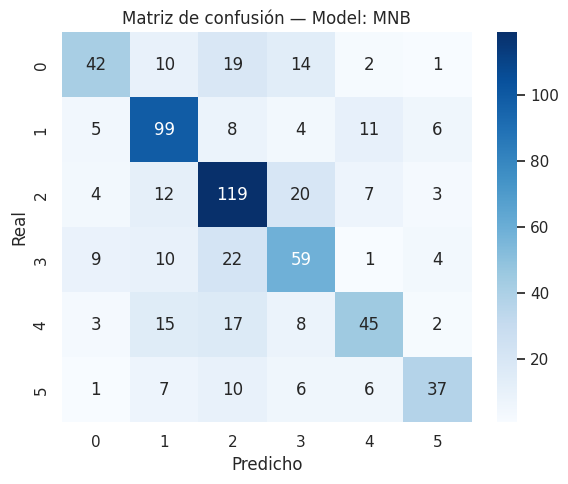

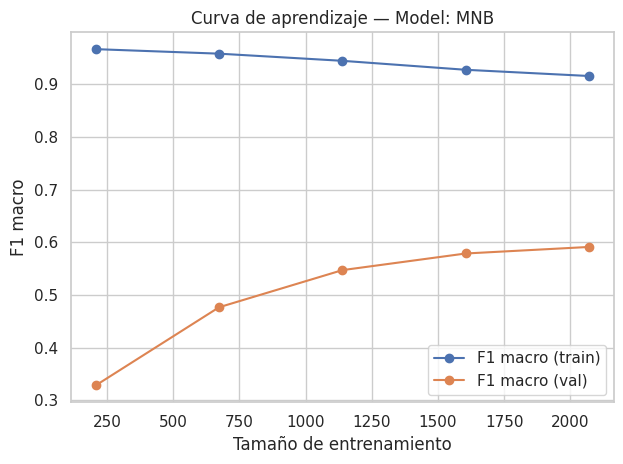


Model: LR
Accuracy: 0.7284 | Macro-F1: 0.7243

              precision    recall  f1-score   support

      joyful       0.68      0.66      0.67        88
         mad       0.81      0.78      0.79       133
    peaceful       0.76      0.73      0.75       165
    powerful       0.66      0.72      0.69       105
         sad       0.67      0.69      0.68        90
      scared       0.76      0.78      0.77        67

    accuracy                           0.73       648
   macro avg       0.72      0.73      0.72       648
weighted avg       0.73      0.73      0.73       648



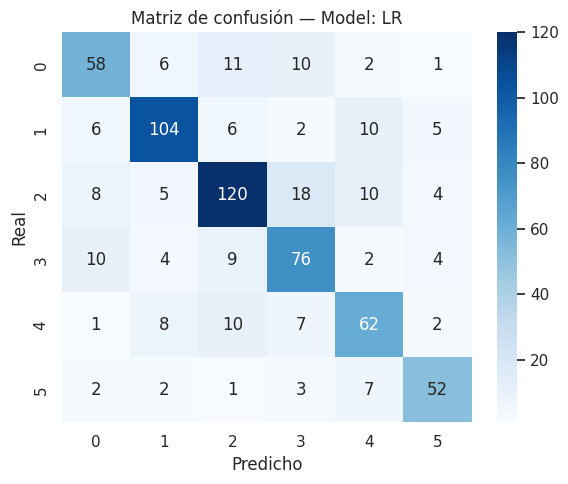

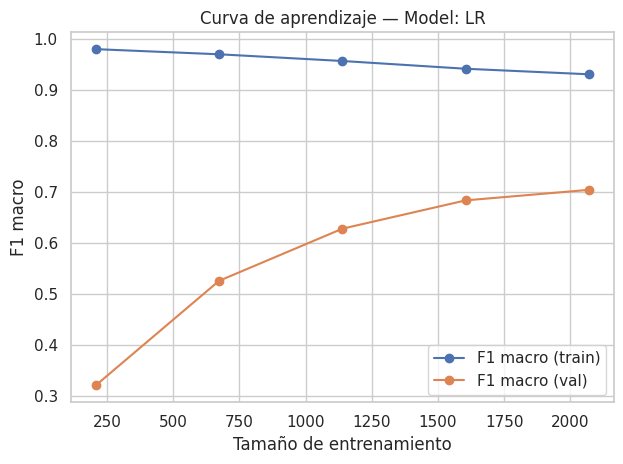


Model: SVM
Accuracy: 0.7361 | Macro-F1: 0.7314

              precision    recall  f1-score   support

      joyful       0.71      0.65      0.68        88
         mad       0.81      0.79      0.80       133
    peaceful       0.79      0.73      0.76       165
    powerful       0.63      0.75      0.68       105
         sad       0.70      0.69      0.69        90
      scared       0.76      0.79      0.77        67

    accuracy                           0.74       648
   macro avg       0.73      0.73      0.73       648
weighted avg       0.74      0.74      0.74       648



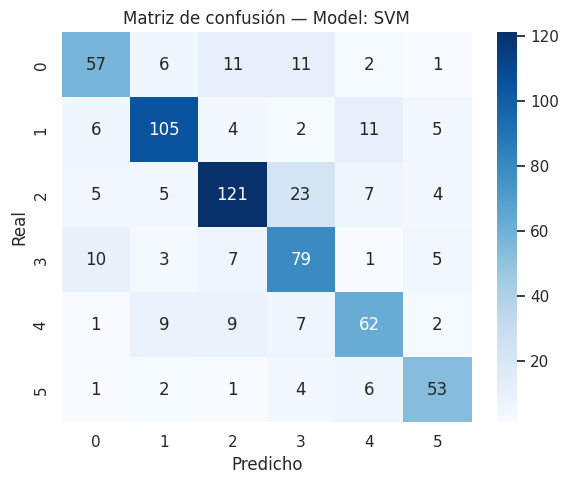

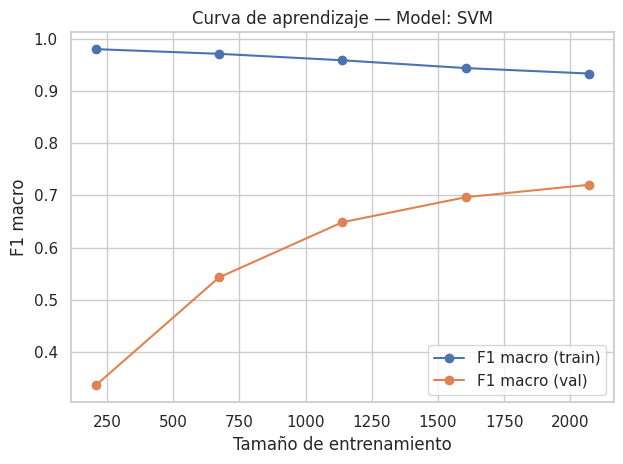

,"Accuracy (stem, tfidf)","F1_macro (stem, tfidf)"
MNB,0.618827,0.604095
LR,0.728395,0.724251
SVM,0.736111,0.731417


In [643]:
# Hacemos la evaluación y la creación de las curvas de aprendizaje que ya tenemos en el diccionario best_models_sent
# obtenemos los resultados para acc (accuracy) y f1 (Parametro F1 del modelo)
# Finalmente hacemos el un plot usando toodos los datos haciendo la validaci
scores_sent_tfidf_s = {}
reports_tfidf_s = {}
for name, model in best_models_sent_tfidf_s.items():
    model_results = evaluate_model(model, X_test_s, y_test_s,
                                   name,
                                   title=f"Model: {name}")
    acc = model_results[f'acc_{model}']
    f1m = model_results[f'f1m_{model}']
    scores_sent_tfidf_s[name] = (acc, f1m)
    reports_tfidf_s[f"report_{name}"] = model_results[f"report_{name}"]
    plot_learning_curves(model, pd.concat([X_train_s, X_test_s]),
                         pd.concat([y_train_s, y_test_s]), cv=5,
                         title=f"Curva de aprendizaje — Model: {name}")

scores_sent_tfidf_s_df = pd.DataFrame(scores_sent_tfidf_s, index=["Accuracy (stem, tfidf)","F1_macro (stem, tfidf)"]).T
scores_sent_tfidf_s_df


Model: MNB
Accuracy: 0.6420 | Macro-F1: 0.6210

              precision    recall  f1-score   support

      joyful       0.71      0.44      0.55        88
         mad       0.63      0.80      0.70       133
    peaceful       0.65      0.72      0.68       165
    powerful       0.61      0.71      0.66       105
         sad       0.60      0.47      0.53        90
      scared       0.71      0.54      0.61        67

    accuracy                           0.64       648
   macro avg       0.65      0.61      0.62       648
weighted avg       0.65      0.64      0.63       648



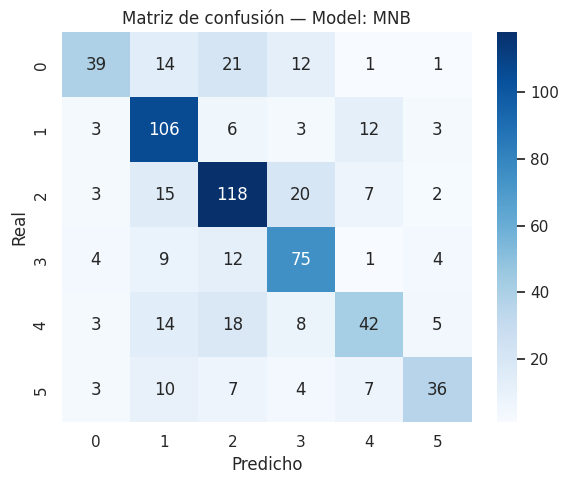

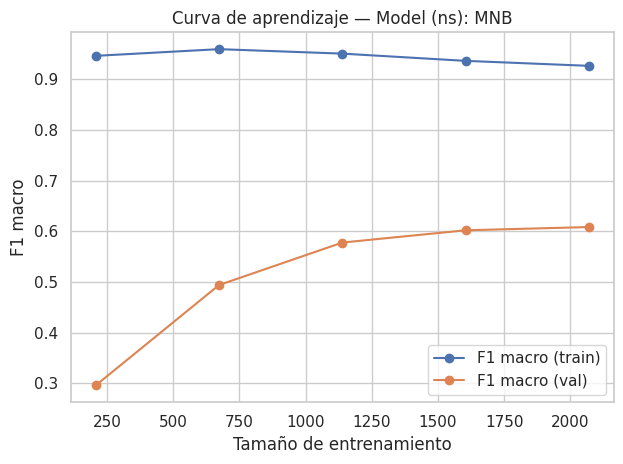


Model: LR
Accuracy: 0.7778 | Macro-F1: 0.7769

              precision    recall  f1-score   support

      joyful       0.82      0.69      0.75        88
         mad       0.81      0.83      0.82       133
    peaceful       0.80      0.77      0.79       165
    powerful       0.68      0.78      0.73       105
         sad       0.74      0.72      0.73        90
      scared       0.82      0.87      0.84        67

    accuracy                           0.78       648
   macro avg       0.78      0.78      0.78       648
weighted avg       0.78      0.78      0.78       648



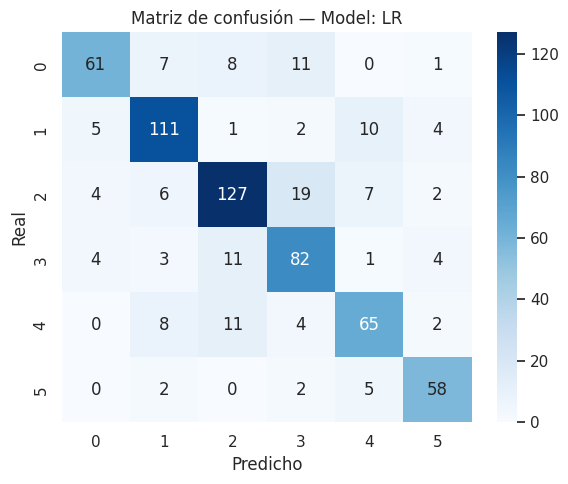

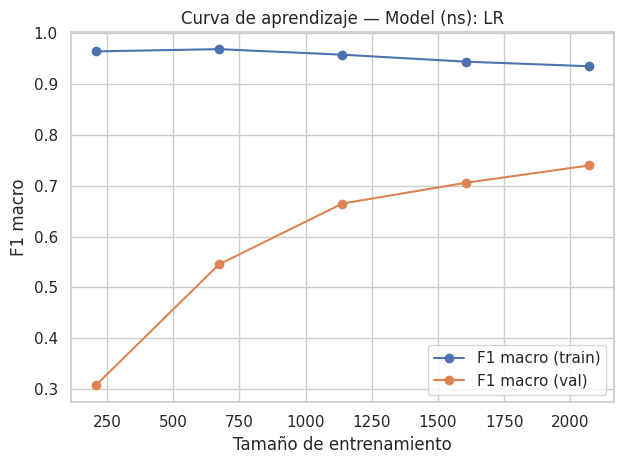


Model: SVM
Accuracy: 0.7855 | Macro-F1: 0.7850

              precision    recall  f1-score   support

      joyful       0.85      0.70      0.77        88
         mad       0.82      0.82      0.82       133
    peaceful       0.82      0.77      0.79       165
    powerful       0.69      0.82      0.75       105
         sad       0.74      0.74      0.74        90
      scared       0.81      0.87      0.83        67

    accuracy                           0.79       648
   macro avg       0.79      0.79      0.79       648
weighted avg       0.79      0.79      0.79       648



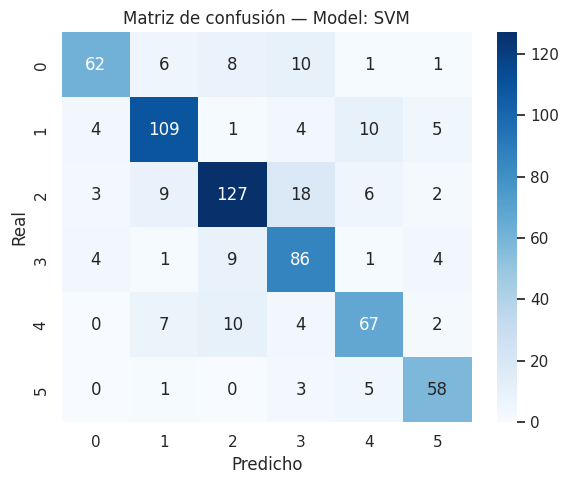

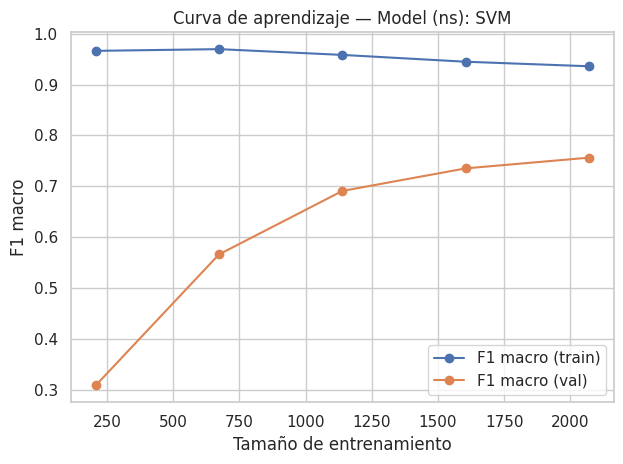

,"Accuracy (no stem, tfidf)","F1_macro (no stem, tfidf)"
MNB,0.641975,0.620975
LR,0.777778,0.776915
SVM,0.785494,0.785048


In [620]:
# Hacemos la evaluación y la creación de las curvas de aprendizaje que ya tenemos en el diccionario best_models_sent
# obtenemos los resultados para acc (accuracy) y f1 (Parametro F1 del modelo)
# Finalmente hacemos el un plot usando toodos los datos haciendo la validacion
scores_sent_tfidf_ns = {}
reports_tfidf_ns = {}
for name, model in best_models_sent_tfidf_ns.items():
    model_results = evaluate_model(model, X_test_ns, y_test_ns,
                                   name,
                                   title=f"Model: {name}")
    acc = model_results[f'acc_{model}']
    f1m = model_results[f'f1m_{model}']
    scores_sent_tfidf_ns[name] = (acc, f1m)
    reports_tfidf_ns[f"report_{name}"] = model_results[f"report_{name}"]
    plot_learning_curves(model, pd.concat([X_train_ns, X_test_ns]),
                         pd.concat([y_train_ns, y_test_ns]), cv=5,
                         title=f"Curva de aprendizaje — Model (ns): {name}")

scores_sent_tfidf_ns_df = pd.DataFrame(scores_sent_tfidf_ns, index=["Accuracy (no stem, tfidf)","F1_macro (no stem, tfidf)"]).T
scores_sent_tfidf_ns_df

In [621]:
reports_tfidf_s

{'report_MNB':               precision    recall  f1-score     support
 joyful         0.656250  0.477273  0.552632   88.000000
 mad            0.647059  0.744361  0.692308  133.000000
 peaceful       0.610256  0.721212  0.661111  165.000000
 powerful       0.531532  0.561905  0.546296  105.000000
 sad            0.625000  0.500000  0.555556   90.000000
 scared         0.698113  0.552239  0.616667   67.000000
 accuracy       0.618827  0.618827  0.618827    0.618827
 macro avg      0.628035  0.592832  0.604095  648.000000
 weighted avg   0.622431  0.618827  0.614922  648.000000,
 'report_LR':               precision    recall  f1-score     support
 joyful         0.682353  0.659091  0.670520   88.000000
 mad            0.806202  0.781955  0.793893  133.000000
 peaceful       0.764331  0.727273  0.745342  165.000000
 powerful       0.655172  0.723810  0.687783  105.000000
 sad            0.666667  0.688889  0.677596   90.000000
 scared         0.764706  0.776119  0.770370   67.000000
 ac

In [622]:
reports_tfidf_ns

{'report_MNB':               precision    recall  f1-score     support
 joyful         0.709091  0.443182  0.545455   88.000000
 mad            0.630952  0.796992  0.704319  133.000000
 peaceful       0.648352  0.715152  0.680115  165.000000
 powerful       0.614754  0.714286  0.660793  105.000000
 sad            0.600000  0.466667  0.525000   90.000000
 scared         0.705882  0.537313  0.610169   67.000000
 accuracy       0.641975  0.641975  0.641975    0.641975
 macro avg      0.651505  0.612265  0.620975  648.000000
 weighted avg   0.646818  0.641975  0.634889  648.000000,
 'report_LR':               precision    recall  f1-score     support
 joyful         0.824324  0.693182  0.753086   88.000000
 mad            0.810219  0.834586  0.822222  133.000000
 peaceful       0.803797  0.769697  0.786378  165.000000
 powerful       0.683333  0.780952  0.728889  105.000000
 sad            0.738636  0.722222  0.730337   90.000000
 scared         0.816901  0.865672  0.840580   67.000000
 ac

In [623]:
top_tfidf_s = {}

for name, model in best_models_sent_tfidf_s.items():
    print("==========================================================================")
    print(f"\n Model (stem): {name} ")
    top = show_top_features(model,"tfidf", top_k=20)
    top_tfidf_s[name] = top



 Model (stem): MNB 

Top for class 'joyful':
['mas' 'si' 'anim' 'ser' 'tan' 'hac' 'esperanz' 'quier' 'bien' 'divert'
 'travesur' 'pued' 'dia' 'gracios' 'atrev' 'pas' 'juerguist' 'mied' 'sab'
 'sol']

Top for class 'mad':
['si' 'mas' 'tan' 'ser' 'molest' 'sol' 'hac' 'sient' 'distant' 'buen'
 'quier' 'frustr' 'habl' 'gent' 'furios' 'bien' 'irrit' 'vid' 'pas'
 'contrari']

Top for class 'peaceful':
['mas' 'ser' 'si' 'amor' 'reconoc' 'agradec' 'rap' 'amo' 'tan' 'hac' 'hoy'
 'person' 'pued' 'buen' 'vid' 'quier' 'pas' 'sol' 'apreci' 'dia']

Top for class 'powerful':
['mas' 'incredul' 'prosper' 'ser' 'logr' 'hac' 'segur' 'vid' 'si' 'año'
 'nuev' 'pued' 'posit' 'qued' 'sorprend' 'cre' 'triunf' 'satisfactori'
 'impact' 'mejor']

Top for class 'sad':
['cans' 'solitari' 'desorient' 'hac' 'sient' 'si' 'adormec' 'dia' 'mas'
 'solter' 'sol' 'fatig' 'flojer' 'perd' 'verd' 'pendej' 'enred' 'qued'
 'dios' 'somnolient']

Top for class 'scared':
['desbord' 'abrum' 'incomod' 'si' 'sient' 'confund' 'desco

In [624]:
top_tfidf_ns = {}

for name, model in best_models_sent_tfidf_ns.items():
    print("==========================================================================")
    print(f"\n Model (no stem): {name} ")
    top = show_top_features(model,"tfidf", top_k=20)
    top_tfidf_ns[name] = top



 Model (no stem): MNB 

Top for class 'joyful':
['mas' 'si' 'animado' 'tan' 'divertido' 'ser' 'bien' 'gracioso'
 'travesura' 'hacer' 'atrevido' 'juerguista' 'dia' 'puede' 'miedo' 'solo'
 'bromista' 'imparable' 'imperturbable' 'desvergonzado']

Top for class 'mad':
['si' 'mas' 'tan' 'ser' 'solo' 'molesto' 'distante' 'frustrado' 'gente'
 'bien' 'furioso' 'vida' 'impotente' 'harto' 'celoso' 'siento'
 'compulsivo' 'desilusionado' 'siempre' 'hoy']

Top for class 'peaceful':
['mas' 'si' 'amo' 'rapido' 'ser' 'tan' 'hoy' 'vida' 'quiero' 'amor' 'solo'
 'dia' 'agradecido' 'reconocimiento' 'atento' 'gracias' 'grato' 'personas'
 'bien' 'tierno']

Top for class 'powerful':
['mas' 'ser' 'si' 'vida' 'año' 'sorprendido' 'logro' 'satisfactorio'
 'prosperidad' 'capaz' 'positivo' 'triunfo' 'triunfador' 'gente'
 'confiado' 'nuevo' 'incredulidad' 'incredulo' 'viendo' 'mejor']

Top for class 'sad':
['cansado' 'solitario' 'si' 'adormecido' 'dia' 'flojera' 'mas' 'soltero'
 'fatigado' 'perdido' 'enredado' 'so

###Analisis por *Bag of words*

In [625]:
bow = CountVectorizer(analyzer=lambda x: x,   # identidad: ya viene tokenizado
                      preprocessor=None,
                      lowercase=False,
                      token_pattern=None,
                      min_df=2,
                      max_df=0.9)


pipelines_bow = {
    "MNB": Pipeline([("bow", bow), ("clf", MultinomialNB())]),
    "LR":  Pipeline([("bow", bow), ("clf", LogisticRegression(max_iter=2000, n_jobs=-1, class_weight="balanced"))]),
    "SVM": Pipeline([("bow", bow), ("clf", LinearSVC(class_weight="balanced"))])
}

param_grids_bow = {
    "MNB": {"bow__ngram_range":[(1,1),(1,2)], "bow__min_df":[1,2,5], "clf__alpha":[0.1,0.5,1.0]},
    "LR":  {"bow__ngram_range":[(1,1),(1,2)], "bow__min_df":[1,2,5], "clf__C":[0.1,1.0,3.0], "clf__penalty":["l2"], "clf__solver":["lbfgs","saga"]},
    "SVM": {"bow__ngram_range":[(1,1),(1,2)], "bow__min_df":[1,2,5], "clf__C":[0.5,1.0,2.0]}
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models_sent_bow_s = {}
best_models_sent_bow_ns = {}
for name, pipe in pipelines_bow.items():
    print(f"=== GridSearch {name} (steming text, BoW) ===")
    grid_bw_s = GridSearchCV(pipe, param_grids_bow[name], scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
    grid_bw_s.fit(X_train_s, y_train_s)
    print("Best parameters:", grid_bw_s.best_params_)
    best_models_sent_bow_s[name] = grid_bw_s.best_estimator_
    print()

    print(f"=== GridSearch {name} (no steming text, BoW) ===")
    grid_bw_ns = GridSearchCV(pipe, param_grids_bow[name], scoring="f1_macro", cv=cv, n_jobs=-1, verbose=1)
    grid_bw_ns.fit(X_train_ns, y_train_ns)
    print("Mejores parameters:", grid_bw_ns.best_params_)
    best_models_sent_bow_ns[name] = grid_bw_ns.best_estimator_
    print()

    best_models_sent_bow_s[f"{name}"] = grid_bw_s.best_estimator_
    best_models_sent_bow_ns[f"{name}"] = grid_bw_ns.best_estimator_


=== GridSearch MNB (steming text, BoW) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'bow__min_df': 2, 'bow__ngram_range': (1, 1), 'clf__alpha': 0.5}

=== GridSearch MNB (no steming text, BoW) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores parameters: {'bow__min_df': 2, 'bow__ngram_range': (1, 1), 'clf__alpha': 0.5}

=== GridSearch LR (steming text, BoW) ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'bow__min_df': 2, 'bow__ngram_range': (1, 1), 'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

=== GridSearch LR (no steming text, BoW) ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parameters: {'bow__min_df': 2, 'bow__ngram_range': (1, 1), 'clf__C': 3.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

=== GridSearch SVM (steming text, BoW) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'bow__min_df': 2, 'bow__ngram_


Model: MNB
Accuracy: 0.6049 | Macro-F1: 0.5888

              precision    recall  f1-score   support

      joyful       0.59      0.50      0.54        88
         mad       0.65      0.74      0.69       133
    peaceful       0.65      0.67      0.66       165
    powerful       0.50      0.54      0.52       105
         sad       0.58      0.51      0.54        90
      scared       0.62      0.54      0.58        67

    accuracy                           0.60       648
   macro avg       0.60      0.58      0.59       648
weighted avg       0.60      0.60      0.60       648



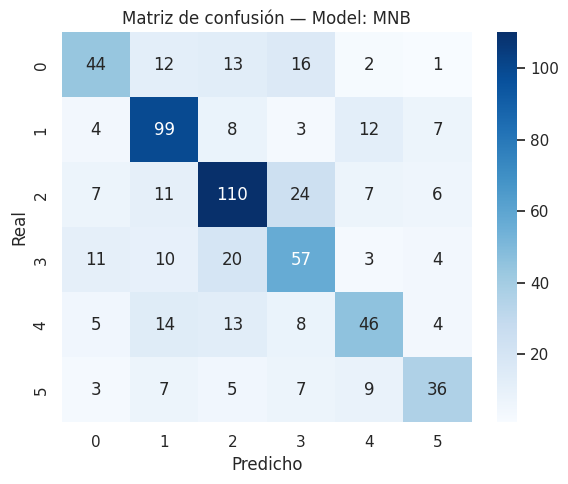

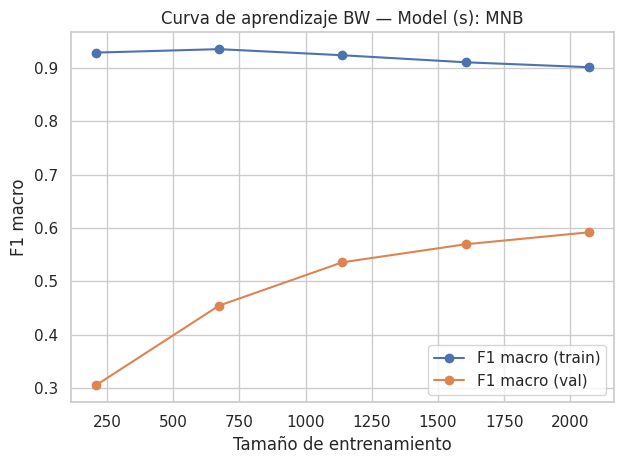


Model: LR
Accuracy: 0.7377 | Macro-F1: 0.7340

              precision    recall  f1-score   support

      joyful       0.71      0.67      0.69        88
         mad       0.80      0.80      0.80       133
    peaceful       0.78      0.74      0.76       165
    powerful       0.64      0.69      0.66       105
         sad       0.68      0.70      0.69        90
      scared       0.77      0.82      0.80        67

    accuracy                           0.74       648
   macro avg       0.73      0.74      0.73       648
weighted avg       0.74      0.74      0.74       648



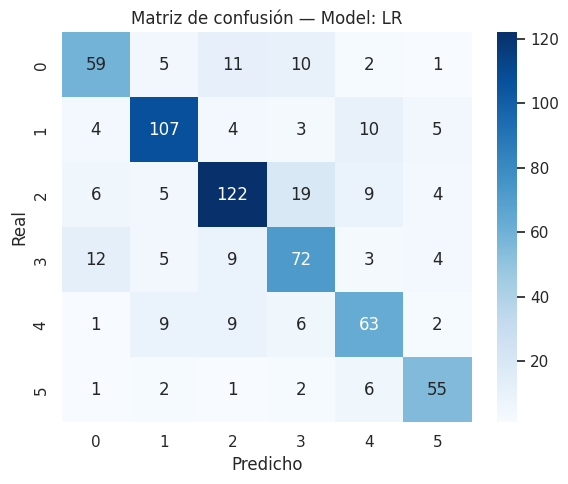

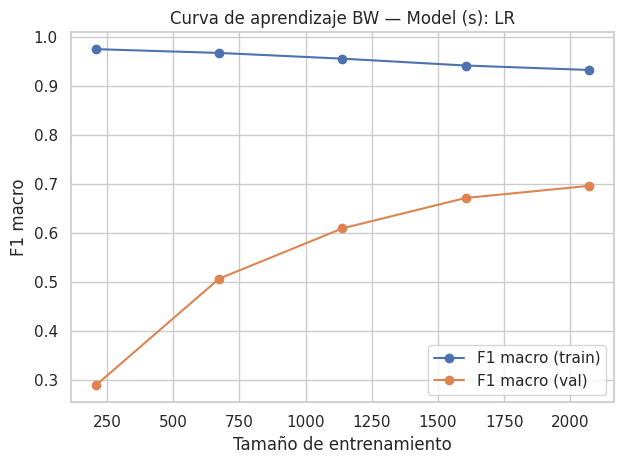


Model: SVM
Accuracy: 0.7438 | Macro-F1: 0.7399

              precision    recall  f1-score   support

      joyful       0.74      0.65      0.69        88
         mad       0.82      0.80      0.81       133
    peaceful       0.78      0.75      0.76       165
    powerful       0.65      0.72      0.68       105
         sad       0.70      0.71      0.71        90
      scared       0.75      0.84      0.79        67

    accuracy                           0.74       648
   macro avg       0.74      0.74      0.74       648
weighted avg       0.75      0.74      0.74       648



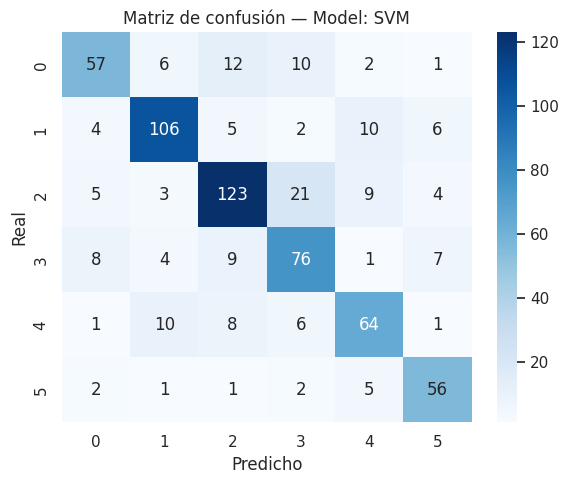

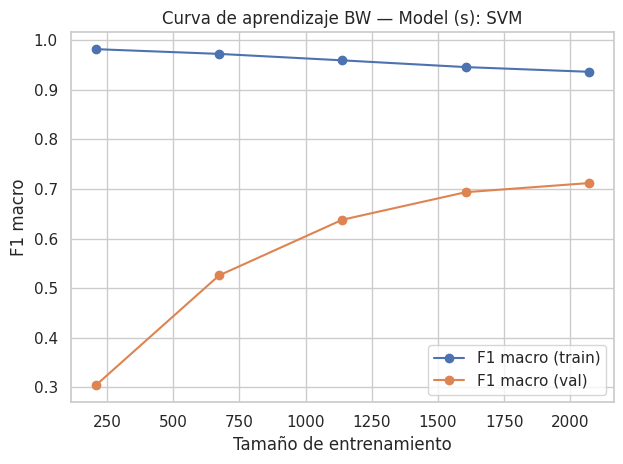

,"Accuracy (stem, bw)","F1_macro (stem, bw)"
MNB,0.604938,0.588793
LR,0.737654,0.733986
SVM,0.743827,0.739867


In [626]:
# Hacemos la evaluación y la creación de las curvas de aprendizaje que ya tenemos en el diccionario best_models_sent
# obtenemos los resultados para acc (accuracy) y f1 (Parametro F1 del modelo)
# Finalmente hacemos el un plot usando toodos los datos haciendo la validaci
scores_sent_bw_s = {}
reports_bw_s = {}
for name, model in best_models_sent_bow_s.items():
    model_results = evaluate_model(model, X_test_s, y_test_s,
                                   name,
                                   title=f"Model: {name}")
    acc = model_results[f'acc_{model}']
    f1m = model_results[f'f1m_{model}']
    scores_sent_bw_s[name] = (acc, f1m)
    reports_bw_s[f"report_{name}"] = model_results[f"report_{name}"]
    plot_learning_curves(model, pd.concat([X_train_s, X_test_s]),
                         pd.concat([y_train_s, y_test_s]), cv=5,
                         title=f"Curva de aprendizaje BW — Model (s): {name}")

scores_sent_bw_s_df = pd.DataFrame(scores_sent_bw_s, index=["Accuracy (stem, bw)","F1_macro (stem, bw)"]).T
scores_sent_bw_s_df





Model: MNB
Accuracy: 0.6435 | Macro-F1: 0.6279

              precision    recall  f1-score   support

      joyful       0.69      0.47      0.56        88
         mad       0.63      0.78      0.70       133
    peaceful       0.69      0.68      0.68       165
    powerful       0.59      0.72      0.65       105
         sad       0.59      0.48      0.53        90
      scared       0.69      0.61      0.65        67

    accuracy                           0.64       648
   macro avg       0.65      0.62      0.63       648
weighted avg       0.65      0.64      0.64       648



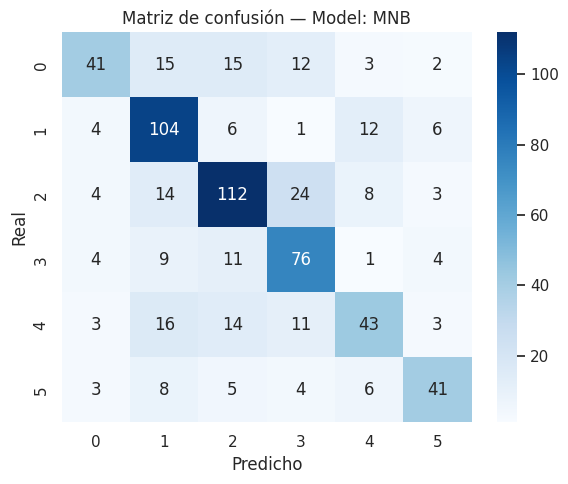

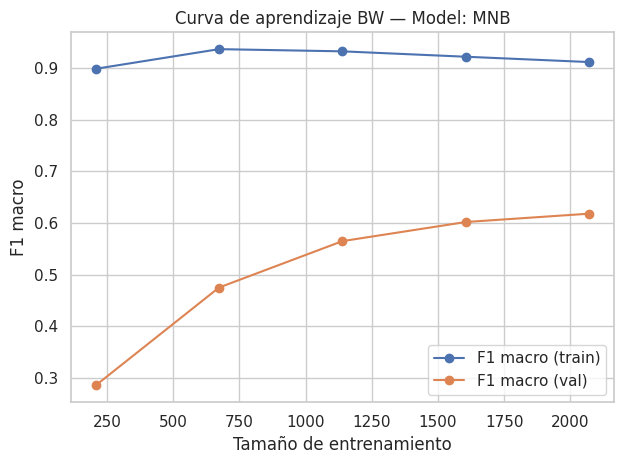


Model: LR
Accuracy: 0.7855 | Macro-F1: 0.7841

              precision    recall  f1-score   support

      joyful       0.80      0.68      0.74        88
         mad       0.82      0.83      0.82       133
    peaceful       0.81      0.79      0.80       165
    powerful       0.72      0.80      0.76       105
         sad       0.72      0.76      0.74        90
      scared       0.85      0.85      0.85        67

    accuracy                           0.79       648
   macro avg       0.79      0.78      0.78       648
weighted avg       0.79      0.79      0.79       648



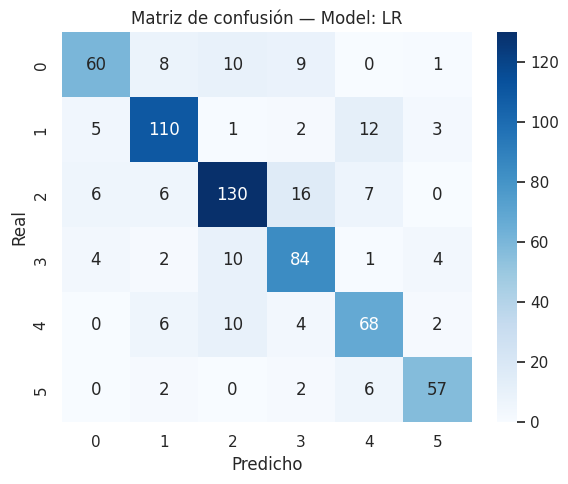

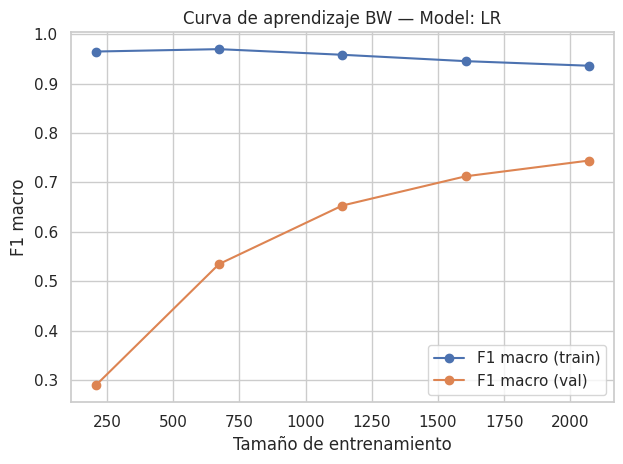


Model: SVM
Accuracy: 0.8009 | Macro-F1: 0.7993

              precision    recall  f1-score   support

      joyful       0.81      0.70      0.75        88
         mad       0.83      0.83      0.83       133
    peaceful       0.82      0.81      0.81       165
    powerful       0.75      0.81      0.78       105
         sad       0.76      0.78      0.77        90
      scared       0.84      0.87      0.85        67

    accuracy                           0.80       648
   macro avg       0.80      0.80      0.80       648
weighted avg       0.80      0.80      0.80       648



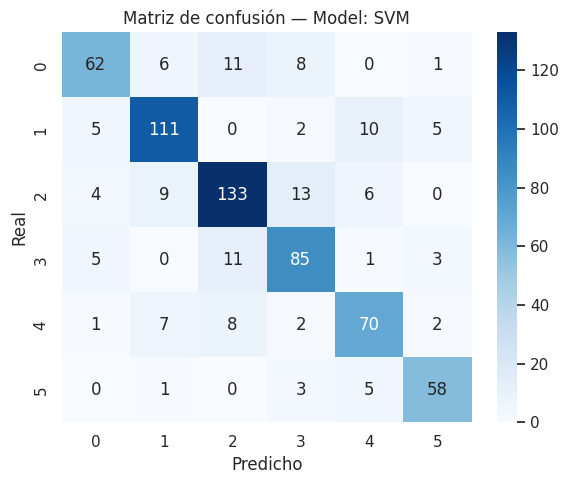

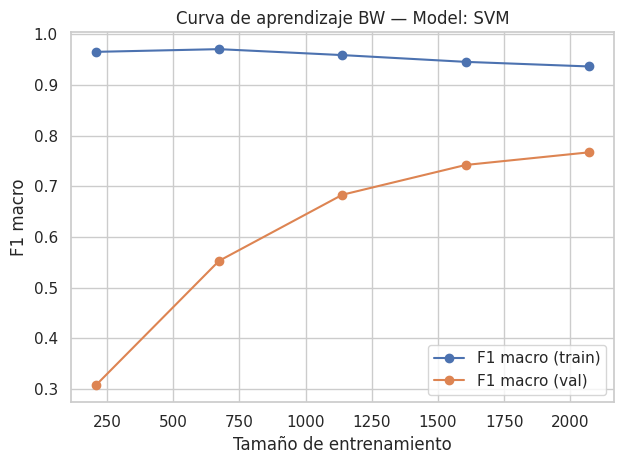

,"Accuracy (no stem, bw)","F1_macro (no stem, bw)"
MNB,0.643519,0.627861
LR,0.785494,0.784058
SVM,0.800926,0.799323


In [627]:
# Hacemos la evaluación y la creación de las curvas de aprendizaje que ya tenemos en el diccionario best_models_sent
# obtenemos los resultados para acc (accuracy) y f1 (Parametro F1 del modelo)
# Finalmente hacemos el un plot usando toodos los datos haciendo la validaci
scores_sent_bw_ns = {}
reports_bw_ns = {}
for name, model in best_models_sent_bow_ns.items():
    model_results = evaluate_model(model, X_test_ns, y_test_ns,
                                   name,
                                   title=f"Model: {name}")
    acc = model_results[f'acc_{model}']
    f1m = model_results[f'f1m_{model}']
    scores_sent_bw_ns[name] = (acc, f1m)
    reports_bw_ns[f"report_{name}"] = model_results[f"report_{name}"]
    plot_learning_curves(model, pd.concat([X_train_ns, X_test_ns]),
                         pd.concat([y_train_ns, y_test_ns]), cv=5,
                         title=f"Curva de aprendizaje BW — Model: {name}")

scores_sent_bw_ns_df = pd.DataFrame(scores_sent_bw_ns, index=["Accuracy (no stem, bw)","F1_macro (no stem, bw)"]).T
scores_sent_bw_ns_df

In [628]:
top_bow_s = {}
for name, model in best_models_sent_bow_s.items():
    print("==========================================================================")
    print(f"\n Model (stem): {name} ")
    top = show_top_features(model, "bow", top_k=20)
    top_bow_s[name] = top



 Model (stem): MNB 

Top for class 'joyful':
['mas' 'si' 'hac' 'ser' 'tan' 'pued' 'anim' 'pas' 'quier' 'sol' 'dia'
 'sab' 'esperanz' 'sin' 'buen' 'dej' 'ver' 'cas' 'va' 'mism']

Top for class 'mad':
['si' 'mas' 'ser' 'sol' 'hac' 'tan' 'gent' 'buen' 'pas' 'sient' 'molest'
 'vid' 'dej' 'habl' 'quier' 'pued' 'bien' 'mal' 'dic' 'ahor']

Top for class 'peaceful':
['mas' 'si' 'ser' 'hac' 'tan' 'reconoc' 'vid' 'person' 'rap' 'pued' 'hoy'
 'sol' 'pas' 'agradec' 'buen' 'amor' 'dej' 'quier' 'dia' 'amo']

Top for class 'powerful':
['mas' 'ser' 'hac' 'si' 'vid' 'pued' 'nuev' 'segur' 'cre' 'buen' 'año'
 'mejor' 'prosper' 'logr' 'qued' 'sol' 'pas' 'gent' 'cambi' 'incredul']

Top for class 'sad':
['mas' 'si' 'hac' 'cans' 'sol' 'sient' 'solitari' 'ser' 'pued' 'dia'
 'desorient' 'quier' 'apart' 'qued' 'perd' 'dej' 'buen' 'dic' 'lad' 'tan']

Top for class 'scared':
['si' 'desbord' 'mas' 'ser' 'hac' 'desconcert' 'sient' 'pas' 'abrum' 'dia'
 'mal' 'quier' 'ver' 'incomod' 'vec' 'perd' 'habi' 'hoy' 'sent' 

In [629]:
top_bow_ns = {}
for name, model in best_models_sent_bow_ns.items():
    print("==========================================================================")
    print(f"\n Model (stem): {name} ")
    top = show_top_features(model, "bow", top_k=20)
    top_bow_ns[name] = top


 Model (stem): MNB 

Top for class 'joyful':
['mas' 'si' 'tan' 'ser' 'animado' 'hacer' 'dia' 'solo' 'puede' 'sino'
 'ver' 'va' 'vida' 'positivo' 'nunca' 'ahora' 'imparable' 'divertido'
 'pensar' 'miedo']

Top for class 'mad':
['si' 'mas' 'ser' 'solo' 'tan' 'gente' 'vida' 'molesto' 'bien' 'ahora'
 'hacer' 'mundo' 'siempre' 'hoy' 'contrariado' 'siento' 'quiero' 'dia'
 'frustrado' 'vez']

Top for class 'peaceful':
['mas' 'si' 'ser' 'tan' 'vida' 'rapido' 'hoy' 'solo' 'dia' 'amo' 'quiero'
 'mismo' 'bien' 'personas' 'gente' 'hacer' 'agradecido' 'dias' 'asi'
 'tiempo']

Top for class 'powerful':
['mas' 'ser' 'si' 'vida' 'año' 'gente' 'tan' 'mejor' 'nuevo' 'hoy' 'solo'
 'ahora' 'mundo' 'bueno' 'hace' 'alguien' 'ver' 'positivo' 'capaz' 'nunca']

Top for class 'sad':
['mas' 'si' 'cansado' 'solitario' 'dia' 'solo' 'ser' 'siento' 'hoy' 'tan'
 'dios' 'apartado' 'perdido' 'asi' 'lado' 'flojera' 'verdad' 'adormecido'
 'ver' 'bts']

Top for class 'scared':
['si' 'mas' 'ser' 'desconcertado' 'abrumado'

# Presentación de resultados

## Coeficiente de efectividad

Concatenamos los resultados para "no stem" y "stem" para le metodo *TF-IDF* y *Bag of Word*. El codigo siguiente hace este proceso para luego mostrar los resultados

In [630]:
scores_sent_tfidf_df = pd.concat([scores_sent_tfidf_ns_df, scores_sent_tfidf_s_df], axis=1)
scores_sent_bw_df = pd.concat([scores_sent_bw_ns_df, scores_sent_bw_s_df], axis=1)
scores_tfidf_columns = scores_sent_tfidf_df.columns
scores_bw_columns = scores_sent_bw_df.columns

scores_tfidf_columns = [scores_tfidf_columns[0],
                        scores_tfidf_columns[2],
                        scores_tfidf_columns[1],
                        scores_tfidf_columns[3]]

scores_bw_columns = [scores_bw_columns[0],
                     scores_bw_columns[2],
                     scores_bw_columns[1],
                     scores_bw_columns[3]]



scores_sent_tfidf_df = scores_sent_tfidf_df[scores_tfidf_columns]
scores_sent_tfidf_df = scores_sent_tfidf_df.reset_index().rename(columns={"index": "Model"})

scores_sent_bw_df = scores_sent_bw_df[scores_bw_columns]
scores_sent_bw_df = scores_sent_bw_df.reset_index().rename(columns={"index": "Model"})


scores_sent_bw_df2 = scores_sent_bw_df.copy()
scores_sent_bw_df2.pop("Model")
scores_sent_df = pd.concat([scores_sent_tfidf_df, scores_sent_bw_df2], axis=1)
score_columns = scores_sent_df.columns
scores_columns = [score_columns[0],
                  score_columns[4],
                  score_columns[1],
                  score_columns[5],
                  score_columns[2],
                  score_columns[6],
                  score_columns[3],
                  score_columns[7]]

scores_sent_df = scores_sent_df[scores_columns]

Valoes de F1 y Accuracy obtenido parra vectorizacion *TF-IDF*

In [631]:
scores_sent_tfidf_df

,Model,"Accuracy (no stem, tfidf)","Accuracy (stem, tfidf)","F1_macro (no stem, tfidf)","F1_macro (stem, tfidf)"
0,MNB,0.641975,0.618827,0.620975,0.604095
1,LR,0.777778,0.728395,0.776915,0.724251
2,SVM,0.785494,0.736111,0.785048,0.731417


Valoes de F1 y Accuracy obtenido parra vectorizacion *Bag of Words*

In [632]:
scores_sent_bw_df

,Model,"Accuracy (no stem, bw)","Accuracy (stem, bw)","F1_macro (no stem, bw)","F1_macro (stem, bw)"
0,MNB,0.643519,0.604938,0.627861,0.588793
1,LR,0.785494,0.737654,0.784058,0.733986
2,SVM,0.800926,0.743827,0.799323,0.739867


Valoes conjuntos para ambos metodos

In [633]:
scores_sent_df

,Model,"F1_macro (stem, tfidf)","Accuracy (no stem, tfidf)","Accuracy (no stem, bw)","Accuracy (stem, tfidf)","Accuracy (stem, bw)","F1_macro (no stem, tfidf)","F1_macro (no stem, bw)"
0,MNB,0.604095,0.641975,0.643519,0.618827,0.604938,0.620975,0.627861
1,LR,0.724251,0.777778,0.785494,0.728395,0.737654,0.776915,0.784058
2,SVM,0.731417,0.785494,0.800926,0.736111,0.743827,0.785048,0.799323


## Analisis de coeficientes de cada modelo (precision, recall )

Ahora formatearemos los resultados de recall, y precision del analisis realizado, para los sets de palabras con stem y sin stem, para lo modelo *TF-IDF* y *Bag of Word*

In [634]:
def dataframe_formating(df_dict, name):
  df = pd.concat(df_dict, axis=1)
  df_flat = df.copy()
  df_flat.columns = df_flat.columns.map(lambda c:
                                        f"{re.sub(r'^report_', '', str(c[0]))}_{c[1]}")
  df_filtered = df_flat.loc[:, ~df_flat.columns.str.contains("f1-score|support")]
  df_filtered = df_filtered.T.reset_index().rename(columns={"index": f"Model for {name}"})

  return df_filtered

Primero para *TF-IDF*

In [648]:
report_tfidf_s = dataframe_formating(reports_tfidf_s, "tfidf (stem)")
report_tfidf_s

,Model for tfidf (stem),joyful,mad,peaceful,powerful,sad,scared,accuracy,macro avg,weighted avg
0,MNB_precision,0.656250,0.647059,0.610256,0.531532,0.625000,0.698113,0.618827,0.628035,0.622431
1,MNB_recall,0.477273,0.744361,0.721212,0.561905,0.500000,0.552239,0.618827,0.592832,0.618827
2,LR_precision,0.682353,0.806202,0.764331,0.655172,0.666667,0.764706,0.728395,0.723238,0.730579
3,LR_recall,0.659091,0.781955,0.727273,0.723810,0.688889,0.776119,0.728395,0.726189,0.728395
4,SVM_precision,0.712500,0.807692,0.790850,0.626984,0.696629,0.757143,0.736111,0.731966,0.740543
5,SVM_recall,0.647727,0.789474,0.733333,0.752381,0.688889,0.791045,0.736111,0.733808,0.736111


In [649]:
report_tfidf_ns = dataframe_formating(reports_tfidf_ns, "tfidf (no stem)")
report_tfidf_ns

,Model for tfidf (no stem),joyful,mad,peaceful,powerful,sad,scared,accuracy,macro avg,weighted avg
0,MNB_precision,0.709091,0.630952,0.648352,0.614754,0.600000,0.705882,0.641975,0.651505,0.646818
1,MNB_recall,0.443182,0.796992,0.715152,0.714286,0.466667,0.537313,0.641975,0.612265,0.641975
2,LR_precision,0.824324,0.810219,0.803797,0.683333,0.738636,0.816901,0.777778,0.779535,0.780688
3,LR_recall,0.693182,0.834586,0.769697,0.780952,0.722222,0.865672,0.777778,0.777719,0.777778
4,SVM_precision,0.849315,0.819549,0.819355,0.688000,0.744444,0.805556,0.785494,0.787703,0.790348
5,SVM_recall,0.704545,0.819549,0.769697,0.819048,0.744444,0.865672,0.785494,0.787159,0.785494


Ahora para *Bag of Words*

In [650]:
report_bow_s = dataframe_formating(reports_bw_s, "bow (stem)")
report_bow_s

,Model for bow (stem),joyful,mad,peaceful,powerful,sad,scared,accuracy,macro avg,weighted avg
0,MNB_precision,0.594595,0.647059,0.650888,0.495652,0.582278,0.620690,0.604938,0.598527,0.604652
1,MNB_recall,0.500000,0.744361,0.666667,0.542857,0.511111,0.537313,0.604938,0.583718,0.604938
2,LR_precision,0.710843,0.804511,0.782051,0.642857,0.677419,0.774648,0.737654,0.732055,0.739139
3,LR_recall,0.670455,0.804511,0.739394,0.685714,0.700000,0.820896,0.737654,0.736828,0.737654
4,SVM_precision,0.740260,0.815385,0.778481,0.649573,0.703297,0.746667,0.743827,0.738944,0.746245
5,SVM_recall,0.647727,0.796992,0.745455,0.723810,0.711111,0.835821,0.743827,0.743486,0.743827


In [651]:
report_bow_ns = dataframe_formating(reports_bw_ns, "bow (no stem)")
report_bow_ns

,Model for bow (no stem),joyful,mad,peaceful,powerful,sad,scared,accuracy,macro avg,weighted avg
0,MNB_precision,0.694915,0.626506,0.687117,0.593750,0.589041,0.694915,0.643519,0.647707,0.647791
1,MNB_recall,0.465909,0.781955,0.678788,0.723810,0.477778,0.611940,0.643519,0.623363,0.643519
2,LR_precision,0.800000,0.820896,0.807453,0.717949,0.723404,0.850746,0.785494,0.786741,0.787500
3,LR_recall,0.681818,0.827068,0.787879,0.800000,0.755556,0.850746,0.785494,0.783844,0.785494
4,SVM_precision,0.805195,0.828358,0.815951,0.752212,0.760870,0.840580,0.800926,0.800528,0.801605
5,SVM_recall,0.704545,0.834586,0.806061,0.809524,0.777778,0.865672,0.800926,0.799694,0.800926


In [639]:
#top_tfidf_s

In [640]:
#top_tfidf_ns

In [641]:
#top_bow_s

In [642]:
#top_bow_ns